# Lecture 3b — The Efficient Frontier, and Why It Lies

### The claim on trial

> **"The optimiser finds the best portfolio."**

In Lecture 3a we chose weights by recipe: equal, or inverse-volatility. It felt crude.
Surely we can do better by *solving* for the best weights rather than guessing them?

We can. In 1952 Harry Markowitz showed exactly how, and won a Nobel Prize for it. The
mathematics is elegant, the solution is unique, and it will produce a portfolio with an
in-sample Sharpe ratio of **2.02** — six times better than the equally weighted portfolio's
0.32.

Then we will test it on data it has not seen, and it will score **0.76** while the equally
weighted portfolio scores **1.82**.

The entire in-sample ranking inverts. This notebook is about why, because the answer is not
"Markowitz was wrong" — the mathematics is impeccable. The answer is that we fed it numbers
we did not actually know, and the optimiser treated our ignorance as information.

### What you will be able to do afterwards

1. Construct a genuine **efficient frontier** by constrained optimisation, and explain why
   the random-weight scatter plots you see everywhere are *not* the frontier.
2. Locate the **tangency portfolio** and the capital allocation line, and see how they move
   with the risk-free rate.
3. Demonstrate the **in-sample / out-of-sample inversion** and explain the mechanism.
4. Explain why mean-variance optimisation is called an **"error maximiser"**, and prove it
   on data where you know the right answer.
5. Apply the cheapest effective fix — **weight constraints** — and quantify how much it
   recovers.

---

## 0. Setup

Same bootstrap and same 44-stock, sector-balanced universe as Lecture 3a, so the two
notebooks are directly comparable.

In [1]:
# =====================================================================
#  AIRM Lecture 3b — bootstrap.  Run once.
# =====================================================================
import sys, subprocess, urllib.request, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

def ensure(pkgs):
    missing = [p for p in pkgs if not _has(p)]
    if missing:
        print(f"Installing {', '.join(missing)} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
def _has(p):
    try: __import__({"scikit-learn": "sklearn"}.get(p, p)); return True
    except ImportError: return False

ensure(["pandas", "numpy", "plotly", "scipy"])

import numpy as np, pandas as pd
from scipy.optimize import minimize
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB: pio.renderers.default = "colab"
np.random.seed(3)

AIRM_TEMPLATE = "plotly_white"
AIRM_COLOURS  = ["#1b4965", "#c1121f", "#5fa8d3", "#e09f3e", "#606c38", "#8e7dbe"]
TRADING_DAYS  = 252

DATA_DIR = Path("airm_data"); DATA_DIR.mkdir(exist_ok=True)
SOURCES = {
    "prices.csv":       "https://raw.githubusercontent.com/plotly/datasets/master/all_stocks_5yr.csv",
    "constituents.csv": "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/main/data/constituents.csv",
}
def fetch(name):
    path = DATA_DIR / name
    if not path.exists():
        print(f"Downloading {name} ...", end=" ")
        urllib.request.urlretrieve(SOURCES[name], path); print("done")
    return path

_raw = pd.read_csv(fetch("prices.csv"), parse_dates=["date"]).rename(columns={"Name": "ticker"})
_con = pd.read_csv(fetch("constituents.csv"))
prices_all = _raw.pivot_table(index="date", columns="ticker", values="close")
SECTOR = _con.set_index("Symbol")["GICS Sector"].to_dict()

PER_SECTOR = 4
_liq = _raw.groupby("ticker")["volume"].mean()
_elig = [t for t in prices_all.columns if t in SECTOR and prices_all[t].notna().all()]
universe = []
for s in sorted({SECTOR[t] for t in _elig}):
    names = [t for t in _elig if SECTOR[t] == s]
    universe += list(_liq[names].nlargest(PER_SECTOR).index)
universe = sorted(universe, key=lambda t: (SECTOR[t], t))

prices  = prices_all[universe]
returns = prices.pct_change(fill_method=None).dropna()
N = len(universe)

# --- the split. Everything hinges on this line. -----------------------
SPLIT_FRAC = 0.60
split_k = int(len(returns) * SPLIT_FRAC)
train, test = returns.iloc[:split_k], returns.iloc[split_k:]

print(f"Universe: {N} stocks | {len(returns)} days total")
print(f"TRAIN: {train.index.min():%b %Y} to {train.index.max():%b %Y} ({len(train)} days)")
print(f"TEST : {test.index.min():%b %Y} to {test.index.max():%b %Y} ({len(test)} days)")
print("\nEvery portfolio below is built using TRAIN only, then judged on TEST.")

Universe: 44 stocks | 1258 days total
TRAIN: Feb 2013 to Feb 2016 (754 days)
TEST : Feb 2016 to Feb 2018 (504 days)

Every portfolio below is built using TRAIN only, then judged on TEST.


---

## 1. What Markowitz actually solves

The mean-variance problem is one line:

> Among all portfolios achieving a target expected return, find the one with the lowest
> variance.

Sweep the target return across its whole range and you trace out the **efficient frontier** —
the set of portfolios you cannot improve without accepting more risk.

It needs exactly two inputs: a vector of expected returns $\mu$, and a covariance matrix
$\Sigma$. Remember that. Almost everything that goes wrong later goes wrong because those two
objects are *estimates* being treated as *facts*.

In [2]:
def ann_mu_cov(rets):
    """Annualised expected returns and covariance matrix."""
    return rets.mean().values * TRADING_DAYS, rets.cov().values * TRADING_DAYS

def port_perf(w, rets):
    """Realised annualised return, volatility and Sharpe of fixed weights on a return set."""
    p = rets.values @ np.asarray(w)
    return (p.mean() * TRADING_DAYS,
            p.std() * np.sqrt(TRADING_DAYS),
            p.mean() / p.std() * np.sqrt(TRADING_DAYS))

_SUM_TO_ONE = {"type": "eq", "fun": lambda w: w.sum() - 1.0}

def min_variance(cov, cap=1.0):
    """Lowest-variance portfolio. Needs Sigma only -- no expected returns."""
    n = cov.shape[0]
    r = minimize(lambda w: w @ cov @ w, np.ones(n)/n,
                 bounds=[(0, cap)]*n, constraints=[_SUM_TO_ONE])
    return r.x

def max_sharpe(mu, cov, rf=0.0, cap=1.0):
    """Highest Sharpe-ratio (tangency) portfolio. Needs BOTH mu and Sigma."""
    n = len(mu)
    obj = lambda w: -((w @ mu - rf) / np.sqrt(w @ cov @ w))
    r = minimize(obj, np.ones(n)/n, bounds=[(0, cap)]*n, constraints=[_SUM_TO_ONE])
    return r.x

def min_vol_at_return(mu, cov, target, cap=1.0):
    """Minimum-variance portfolio achieving a given expected return. One frontier point."""
    n = len(mu)
    cons = [_SUM_TO_ONE, {"type": "eq", "fun": lambda w: w @ mu - target}]
    r = minimize(lambda w: w @ cov @ w, np.ones(n)/n, bounds=[(0, cap)]*n, constraints=cons)
    return r.x if r.success else None

def efficient_frontier(mu, cov, n_points=40, cap=1.0):
    """Trace the frontier by solving the optimisation once per target return."""
    targets = np.linspace(mu.min() * 0.9, mu.max() * 0.99, n_points)
    rows = []
    for t in targets:
        w = min_vol_at_return(mu, cov, t, cap=cap)
        if w is not None:
            rows.append({"target": t, "vol": np.sqrt(w @ cov @ w),
                         "ret": w @ mu, "weights": w})
    return pd.DataFrame(rows)

mu_tr, cov_tr = ann_mu_cov(train)
frontier = efficient_frontier(mu_tr, cov_tr)
print(f"Frontier traced: {len(frontier)} portfolios, each a separate optimisation.")
print(f"Volatility range {frontier['vol'].min():.1%} to {frontier['vol'].max():.1%}")

Frontier traced: 40 portfolios, each a separate optimisation.
Volatility range 10.8% to 45.6%


### The random-weight cloud is not the frontier

You have almost certainly seen the efficient frontier illustrated by scattering thousands of
random portfolios and admiring the upper edge of the cloud. It is a lovely picture and it is
**badly misleading**, especially as the number of assets grows.

Random weights that sum to one concentrate near equal weight — the more assets, the tighter
that concentration. So the cloud collapses towards the middle of the space and never gets
anywhere near the corners where the optimiser lives. Let us put both on one chart.

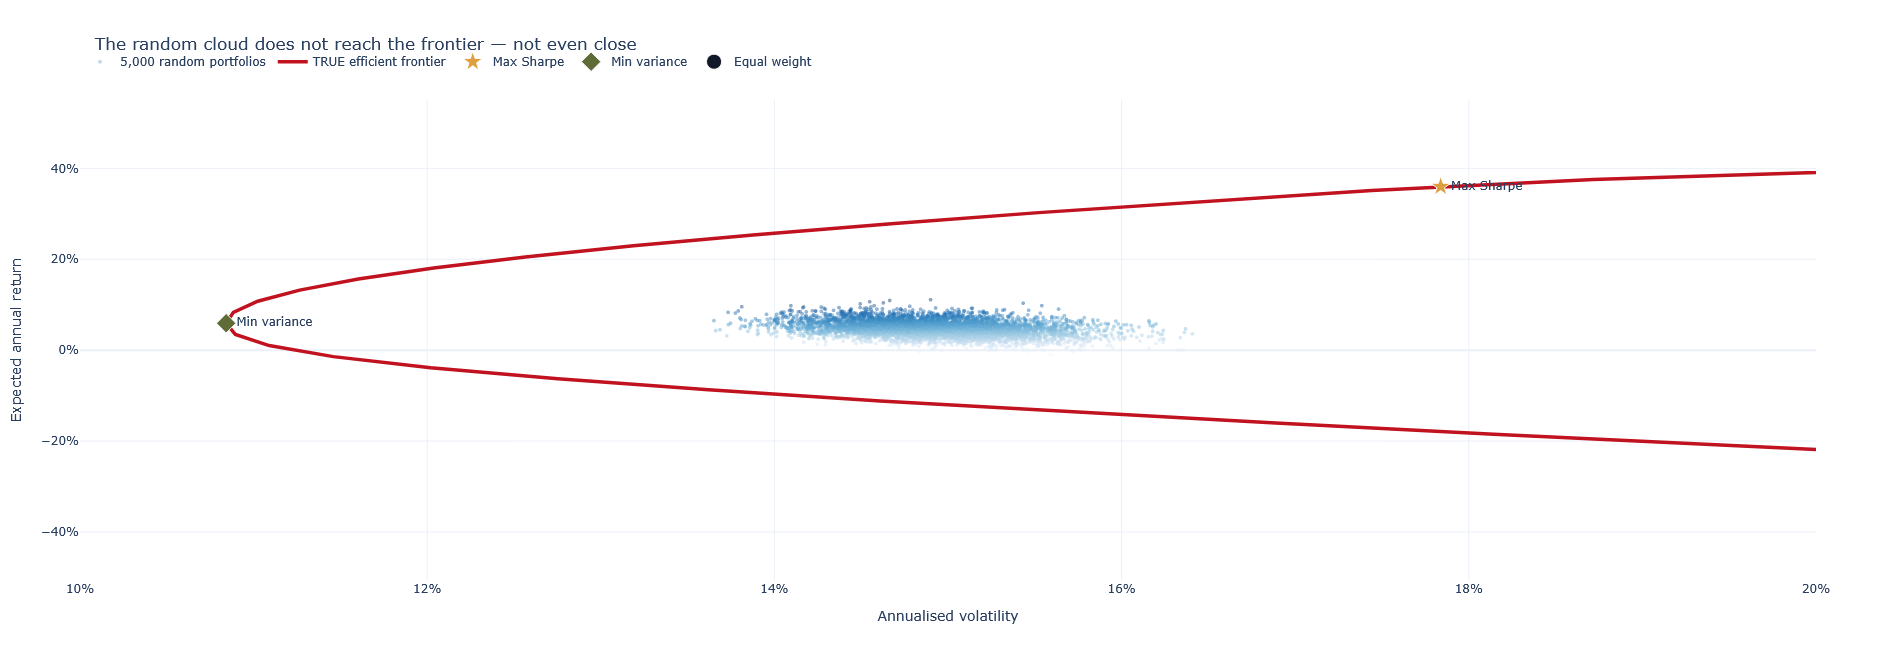

Best Sharpe among 5,000 random portfolios : 0.75
Sharpe of the actual optimum              : 2.02
Highest return reachable by random weights: 11.1%
Highest return on the true frontier       : 49.8%

The cloud captures only 37% of the achievable Sharpe ratio.


In [4]:
# 5,000 random long-only portfolios, the usual way this gets drawn.
rng = np.random.default_rng(0)
W_rand = rng.random((5000, N))
W_rand /= W_rand.sum(axis=1, keepdims=True)
rand_vol = np.sqrt(np.einsum("ij,jk,ik->i", W_rand, cov_tr, W_rand))
rand_ret = W_rand @ mu_tr

w_ms  = max_sharpe(mu_tr, cov_tr)
w_mv  = min_variance(cov_tr)
w_eq  = np.ones(N) / N
inv   = 1 / train.std().values
w_iv  = inv / inv.sum()

fig = go.Figure()
fig.add_trace(go.Scattergl(x=rand_vol, y=rand_ret, mode="markers", name="5,000 random portfolios",
                           marker=dict(size=4, color=rand_ret/rand_vol, colorscale="Blues",
                                       opacity=0.45, showscale=False)))
fig.add_trace(go.Scatter(x=frontier["vol"], y=frontier["ret"], mode="lines",
                         name="TRUE efficient frontier",
                         line=dict(color=AIRM_COLOURS[1], width=3.5)))
for label, w, colour, sym in [("Max Sharpe", w_ms, AIRM_COLOURS[3], "star"),
                              ("Min variance", w_mv, AIRM_COLOURS[4], "diamond"),
                              ("Equal weight", w_eq, "#111827", "circle")]:
    v = np.sqrt(w @ cov_tr @ w); r = w @ mu_tr
    fig.add_trace(go.Scatter(x=[v], y=[r], mode="markers+text", name=label,
                             text=[label], textposition="middle right",
                             marker=dict(size=15, color=colour, symbol=sym,
                                         line=dict(color="white", width=1))))
fig.update_layout(title="The random cloud does not reach the frontier — not even close",
                  template=AIRM_TEMPLATE, height=660,
                  xaxis=dict(title="Annualised volatility", tickformat=".0%",range=[0.1, 0.20]),
                  yaxis=dict(title="Expected annual return", tickformat=".0%"),
                  legend=dict(orientation="h", y=1.11))
fig.show()

print(f"Best Sharpe among 5,000 random portfolios : {(rand_ret/rand_vol).max():.2f}")
print(f"Sharpe of the actual optimum              : {(w_ms@mu_tr)/np.sqrt(w_ms@cov_tr@w_ms):.2f}")
print(f"Highest return reachable by random weights: {rand_ret.max():.1%}")
print(f"Highest return on the true frontier       : {frontier['ret'].max():.1%}")
print(f"\nThe cloud captures only {(rand_ret/rand_vol).max()/((w_ms@mu_tr)/np.sqrt(w_ms@cov_tr@w_ms)):.0%} "
      "of the achievable Sharpe ratio.")

The random cloud tops out at a Sharpe of 0.75 while the true optimum reaches 2.02 — it finds
barely a third of what is there. And it reaches a maximum return of 11% where the frontier
reaches 50%. If you have been taught the frontier via random scatter plots, you have been
looking at a picture of the *interior* of the feasible set.

**Every frontier point above is a separate constrained optimisation.** That is the honest way
to draw it.

<details>
<summary><b>The optimisation problem, formally</b></summary>

For a target return $\mu^\star$, long-only and fully invested:

$$\min_{w} \; w^\top \Sigma w
\quad \text{subject to} \quad w^\top \mu = \mu^\star, \;\; \mathbf{1}^\top w = 1, \;\; w \ge 0$$

This is a **quadratic program**: convex, so there is a unique global optimum and a solver
will find it reliably. Without the $w \ge 0$ constraint there is even a closed-form solution
via Lagrange multipliers, involving $\Sigma^{-1}$.

That $\Sigma^{-1}$ is the villain of this notebook. Inverting an estimated covariance matrix
amplifies whichever directions were estimated least reliably — precisely the small
eigenvalues, which are mostly noise. Lecture 3c attacks exactly this.

Why the random cloud fails: for weights drawn uniformly on the simplex,
$\mathbb{E}[w_i] = 1/N$ with standard deviation $O(1/N)$. As $N$ grows, random portfolios
converge on equal weight, so the cloud shrinks to a point rather than exploring the space.
With $N = 44$ it is hopeless.

</details>

## 2. The tangency portfolio and the risk-free rate

Add a risk-free asset and the picture changes. You can now hold any mix of the risk-free
asset and one particular risky portfolio, generating a straight line — the **capital
allocation line**. The best such line is the steepest one, which touches the frontier at the
**tangency portfolio**: the maximum-Sharpe portfolio.

Move the slider to see where the tangency point sits as the risk-free rate changes.

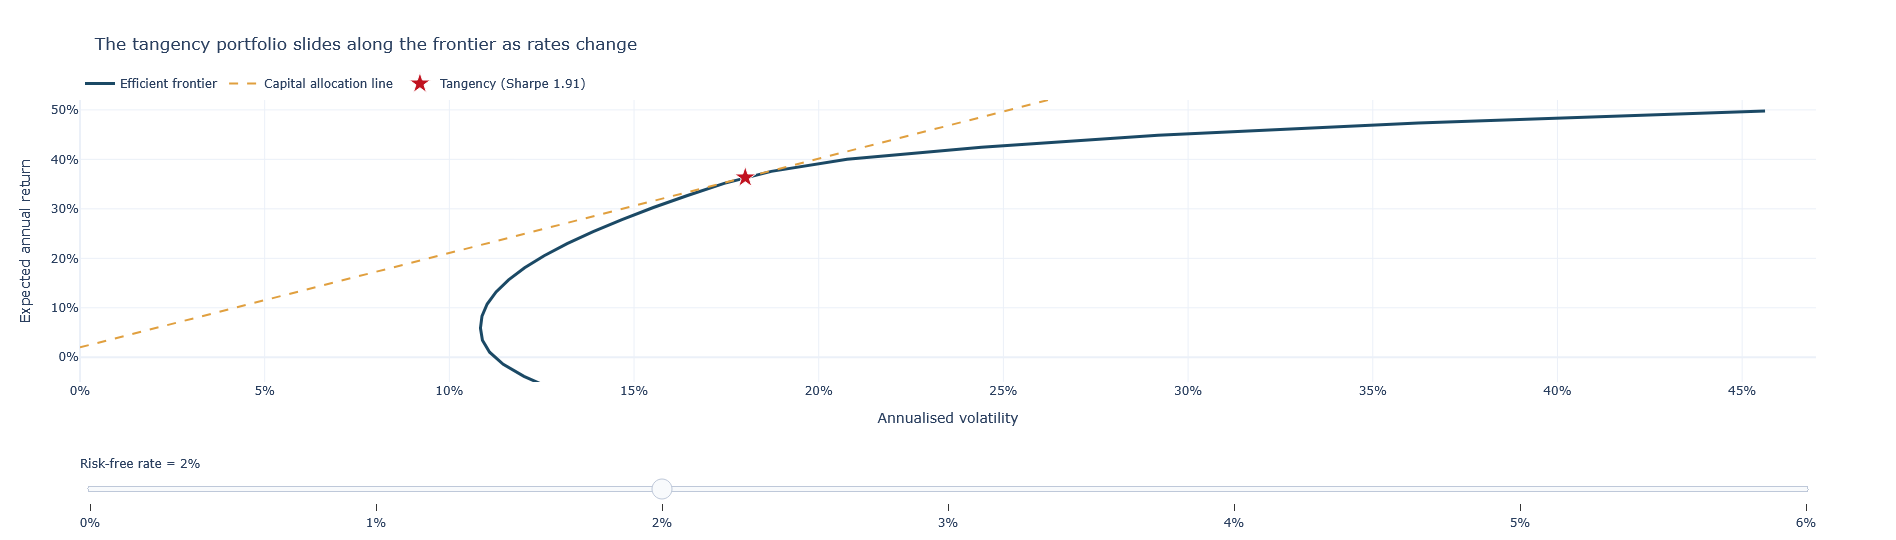

In [5]:
rf_grid = np.round(np.arange(0.0, 0.061, 0.01), 3)

fig = go.Figure()
fig.add_trace(go.Scatter(x=frontier["vol"], y=frontier["ret"], mode="lines",
                         name="Efficient frontier", showlegend=True,
                         line=dict(color=AIRM_COLOURS[0], width=3)))

for k, rf in enumerate(rf_grid):
    w_t = max_sharpe(mu_tr, cov_tr, rf=rf)
    v_t, r_t = np.sqrt(w_t @ cov_tr @ w_t), w_t @ mu_tr
    sharpe = (r_t - rf) / v_t
    x_line = np.array([0, frontier["vol"].max()])
    fig.add_trace(go.Scatter(x=x_line, y=rf + sharpe * x_line, mode="lines",
                             visible=(rf == 0.02), name="Capital allocation line",
                             line=dict(color=AIRM_COLOURS[3], width=2, dash="dash")))
    fig.add_trace(go.Scatter(x=[v_t], y=[r_t], mode="markers", visible=(rf == 0.02),
                             name=f"Tangency (Sharpe {sharpe:.2f})",
                             marker=dict(size=16, color=AIRM_COLOURS[1], symbol="star",
                                         line=dict(color="white", width=1))))

steps = []
for k, rf in enumerate(rf_grid):
    vis = [True] + [False] * (2 * len(rf_grid))
    vis[1 + 2*k] = vis[2 + 2*k] = True
    steps.append(dict(label=f"{rf:.0%}", method="update", args=[{"visible": vis}]))

fig.update_layout(title="The tangency portfolio slides along the frontier as rates change",
                  template=AIRM_TEMPLATE, height=540,
                  xaxis=dict(title="Annualised volatility", tickformat=".0%", range=[0, 0.47]),
                  yaxis=dict(title="Expected annual return", tickformat=".0%", range=[-0.05, 0.52]),
                  legend=dict(orientation="h", y=1.11),
                  sliders=[dict(active=2, pad=dict(t=70),
                                currentvalue=dict(prefix="Risk-free rate = "), steps=steps)])
fig.show()

## 3. Look at what it wants you to buy

Before we test anything, inspect the optimiser's answer. This is the step most people skip,
and it is where the problem is already visible to the naked eye.

In [6]:
weights_tbl = pd.DataFrame({
    "Max Sharpe": w_ms, "Min variance": w_mv,
    "Inverse vol": w_iv, "Equal weight": w_eq}, index=universe)

held = weights_tbl[weights_tbl["Max Sharpe"] > 0.001].sort_values("Max Sharpe", ascending=False)
print("Every stock the max-Sharpe portfolio actually holds:\n")
print(held[["Max Sharpe"]].to_string(formatters={"Max Sharpe": "{:.1%}".format}))
print(f"\n{len(held)} positions out of {N} available.")
print(f"Largest single weight: {w_ms.max():.1%}")
print(f"Top 3 positions      : {np.sort(w_ms)[::-1][:3].sum():.1%} of the portfolio")
print(f"\nSectors represented  : {len({SECTOR[t] for t in held.index})} of "
      f"{len({SECTOR[t] for t in universe})}")

Every stock the max-Sharpe portfolio actually holds:

     Max Sharpe
KR        48.6%
LUV       23.7%
NFLX      10.1%
BSX        8.0%
MSFT       5.8%
GILD       3.8%

6 positions out of 44 available.
Largest single weight: 48.6%
Top 3 positions      : 82.4% of the portfolio

Sectors represented  : 5 of 11


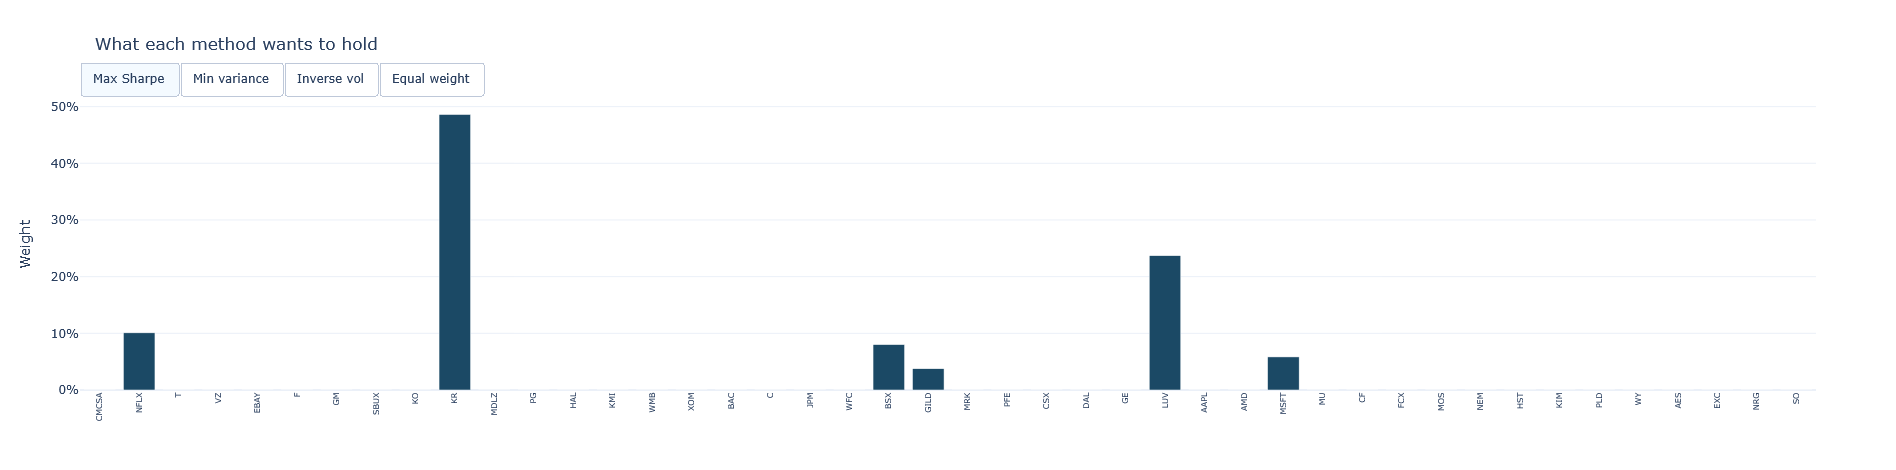

Click through the four. Max Sharpe is a handful of spikes; equal weight is a flat
line. A portfolio manager shown that first chart would ask what the model knows
about those six companies that justifies ignoring the other thirty-eight.
The answer, as we are about to see, is: nothing.


In [8]:
fig = go.Figure()
for i, col in enumerate(["Max Sharpe", "Min variance", "Inverse vol", "Equal weight"]):
    fig.add_trace(go.Bar(x=universe, y=weights_tbl[col], name=col,
                         marker_color=AIRM_COLOURS[i], visible=(i == 0)))
fig.update_layout(
    title="What each method wants to hold",
    template=AIRM_TEMPLATE, height=470,
    yaxis=dict(title="Weight", tickformat=".0%"),
    xaxis=dict(tickangle=-90, tickfont=dict(size=8)), showlegend=False,
    updatemenus=[dict(type="buttons", direction="right", x=0, y=1.13, xanchor="left",
        buttons=[dict(label=c, method="update",
                      args=[{"visible": [j == i for j in range(4)]}])
                 for i, c in enumerate(["Max Sharpe", "Min variance",
                                        "Inverse vol", "Equal weight"])])])
fig.show()

print("Click through the four. Max Sharpe is a handful of spikes; equal weight is a flat")
print("line. A portfolio manager shown that first chart would ask what the model knows")
print("about those six companies that justifies ignoring the other thirty-eight.")
print("The answer, as we are about to see, is: nothing.")

---

## 4. The reveal

Everything so far used the **training** period only. Now we take those exact weights, hold
them fixed, and measure what they earned over the following two years — data the optimiser
never saw.

In [9]:
methods = {"Max Sharpe": w_ms, "Min variance": w_mv,
           "Inverse vol": w_iv, "Equal weight": w_eq}

rows = []
for name, w in methods.items():
    r_in, v_in, s_in = port_perf(w, train)
    r_out, v_out, s_out = port_perf(w, test)
    rows.append({"Portfolio": name,
                 "Sharpe IN": s_in, "Sharpe OUT": s_out,
                 "Retained": s_out / s_in,
                 "Return OUT": r_out, "Vol OUT": v_out,
                 "Max weight": w.max(), "Holdings": int((w > 0.01).sum())})

results = pd.DataFrame(rows).set_index("Portfolio")
results["Rank IN"] = results["Sharpe IN"].rank(ascending=False).astype(int)
results["Rank OUT"] = results["Sharpe OUT"].rank(ascending=False).astype(int)

results[["Sharpe IN", "Rank IN", "Sharpe OUT", "Rank OUT",
         "Max weight", "Holdings"]].style.format(
    {"Sharpe IN": "{:.2f}", "Sharpe OUT": "{:.2f}",
     "Max weight": "{:.1%}", "Rank IN": "{:.0f}", "Rank OUT": "{:.0f}",
     "Holdings": "{:.0f}"}).background_gradient(
    subset=["Sharpe OUT"], cmap="RdYlGn")

,Sharpe IN,Rank IN,Sharpe OUT,Rank OUT,Max weight,Holdings
Portfolio,,,,,,
Max Sharpe,2.02,1,0.76,3,48.6%,6
Min variance,0.55,2,0.44,4,25.4%,12
Inverse vol,0.43,3,1.49,2,3.6%,44
Equal weight,0.32,4,1.82,1,2.3%,44


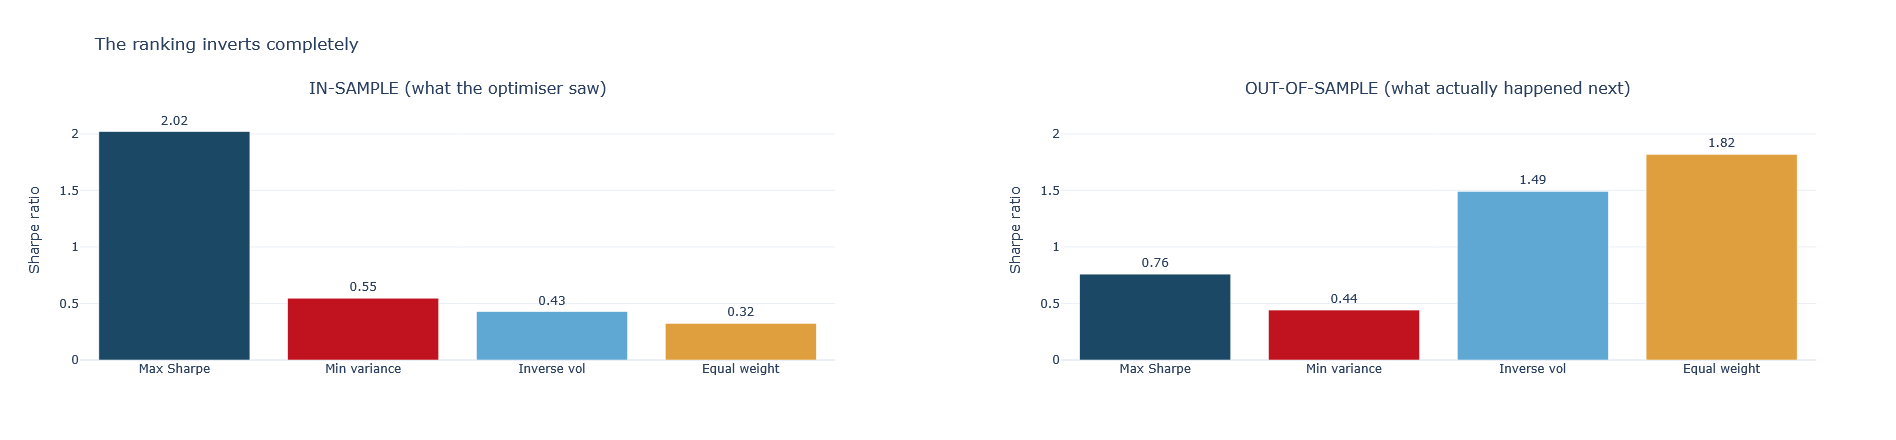

In [10]:
fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.13,
                    subplot_titles=("IN-SAMPLE (what the optimiser saw)",
                                    "OUT-OF-SAMPLE (what actually happened next)"))
order = list(methods)
colours = [AIRM_COLOURS[i] for i in range(len(order))]
fig.add_trace(go.Bar(x=order, y=results.loc[order, "Sharpe IN"], marker_color=colours,
                     text=[f"{v:.2f}" for v in results.loc[order, "Sharpe IN"]],
                     textposition="outside", showlegend=False), 1, 1)
fig.add_trace(go.Bar(x=order, y=results.loc[order, "Sharpe OUT"], marker_color=colours,
                     text=[f"{v:.2f}" for v in results.loc[order, "Sharpe OUT"]],
                     textposition="outside", showlegend=False), 1, 2)
fig.update_yaxes(title_text="Sharpe ratio", range=[0, 2.3])
fig.update_layout(title="The ranking inverts completely",
                  template=AIRM_TEMPLATE, height=440)
fig.show()

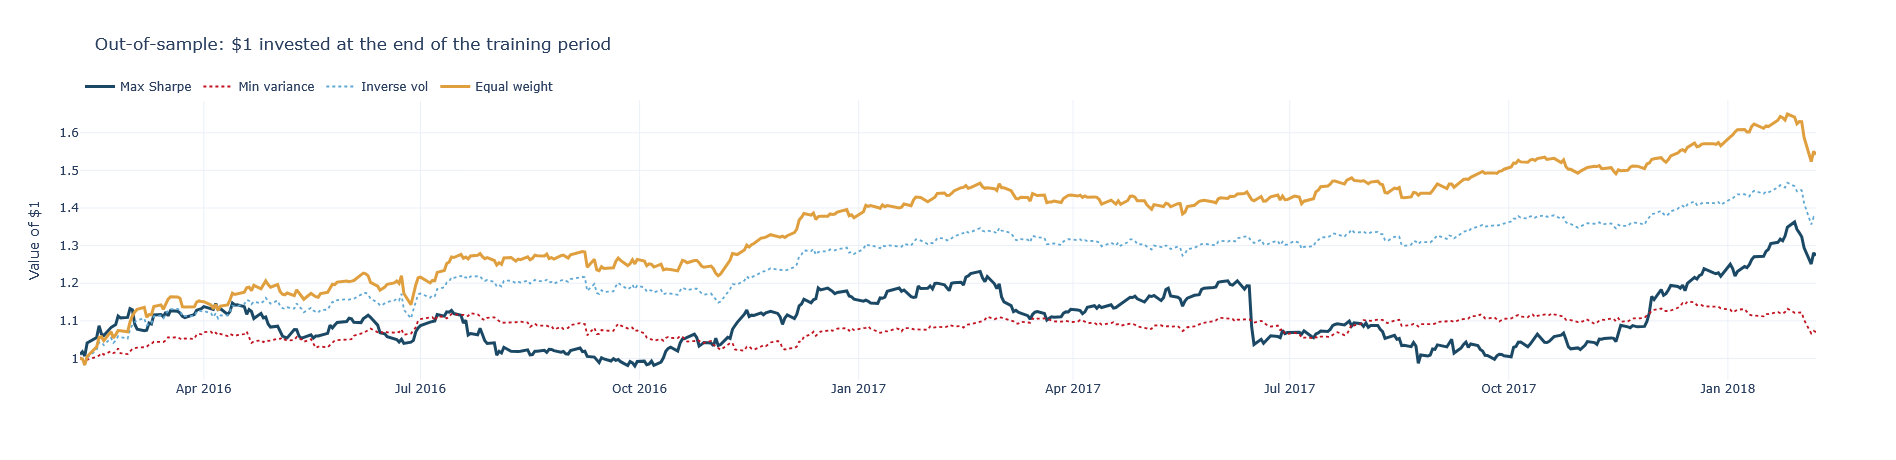

Max Sharpe : in-sample 2.02 -> out-of-sample 0.76 (retained 38%)
Equal weight: in-sample 0.32 -> out-of-sample 1.82

The portfolio that looked SIX TIMES better in-sample finished well behind the
one that required no estimation, no optimisation and no thought whatsoever.


In [11]:
fig = go.Figure()
for i, (name, w) in enumerate(methods.items()):
    curve = (1 + test.values @ w).cumprod()
    fig.add_trace(go.Scatter(x=test.index, y=curve, name=name,
                             line=dict(color=AIRM_COLOURS[i],
                                       width=3 if name in ("Max Sharpe", "Equal weight") else 1.8,
                                       dash=None if name in ("Max Sharpe", "Equal weight") else "dot")))
fig.update_layout(title="Out-of-sample: $1 invested at the end of the training period",
                  template=AIRM_TEMPLATE, height=460, hovermode="x unified",
                  yaxis_title="Value of $1", legend=dict(orientation="h", y=1.1))
fig.show()

print(f"Max Sharpe : in-sample {results.loc['Max Sharpe','Sharpe IN']:.2f} "
      f"-> out-of-sample {results.loc['Max Sharpe','Sharpe OUT']:.2f} "
      f"(retained {results.loc['Max Sharpe','Retained']:.0%})")
print(f"Equal weight: in-sample {results.loc['Equal weight','Sharpe IN']:.2f} "
      f"-> out-of-sample {results.loc['Equal weight','Sharpe OUT']:.2f}")
print("\nThe portfolio that looked SIX TIMES better in-sample finished well behind the")
print("one that required no estimation, no optimisation and no thought whatsoever.")

### This is not a fluke, it is a famous result

DeMiguel, Garlappi and Uppal published exactly this comparison in 2009 across many datasets
and many optimisation variants, under a title that says it all: *Optimal Versus Naive
Diversification: How Inefficient is the 1/N Portfolio Strategy?* The answer, repeatedly, was
that 1/N is *not* inefficient — it beat sample-based mean-variance optimisation out of sample
in most of the cases they tested.

Our two-line experiment reproduces a result that occupies a large literature. Which raises
the real question: **why?**

---

## 5. Why: the optimiser maximises error

Here is the cleanest possible demonstration. We build a world where **we know the right
answer**.

Twenty assets. Every one has *identical* true expected return, *identical* true volatility,
and *zero* true correlation with the others. By construction, they are interchangeable, so
the correct portfolio is unambiguously equal weight — 5% each. There is genuinely nothing to
optimise.

Then we give the optimiser one year of simulated data and let it choose.

In [12]:
rng_sim = np.random.default_rng(7)
n_assets, n_days = 20, 252
TRUE_MU, TRUE_SIG = 0.08, 0.22          # identical for every asset

sim = rng_sim.normal(TRUE_MU/TRADING_DAYS, TRUE_SIG/np.sqrt(TRADING_DAYS),
                     (n_days, n_assets))
sim_df = pd.DataFrame(sim, columns=[f"A{i+1:02d}" for i in range(n_assets)])
mu_s, cov_s = ann_mu_cov(sim_df)
w_sim = max_sharpe(mu_s, cov_s)

print(f"TRUTH: all {n_assets} assets identical -- mu = {TRUE_MU:.0%}, sigma = {TRUE_SIG:.0%}, "
      f"correlation = 0")
print(f"CORRECT ANSWER: equal weight, {1/n_assets:.0%} each\n")
print(f"Sample means ranged from {mu_s.min():.1%} to {mu_s.max():.1%} "
      f"-- pure luck, since the truth is {TRUE_MU:.0%} for all of them.")
print(f"\nOPTIMISER'S ANSWER:")
print(f"  largest weight    : {w_sim.max():.1%}  (correct: {1/n_assets:.0%})")
print(f"  positions held    : {(w_sim > 0.01).sum()} of {n_assets}")
print(f"  top 3 weights sum : {np.sort(w_sim)[::-1][:3].sum():.0%}")
print(f"  it favoured the asset whose sample mean was luckiest: "
      f"{sim_df.columns[np.argmax(mu_s)]} at {mu_s.max():.1%}")

TRUTH: all 20 assets identical -- mu = 8%, sigma = 22%, correlation = 0
CORRECT ANSWER: equal weight, 5% each

Sample means ranged from -41.9% to 40.3% -- pure luck, since the truth is 8% for all of them.

OPTIMISER'S ANSWER:
  largest weight    : 23.0%  (correct: 5%)
  positions held    : 8 of 20
  top 3 weights sum : 62%
  it favoured the asset whose sample mean was luckiest: A05 at 40.3%


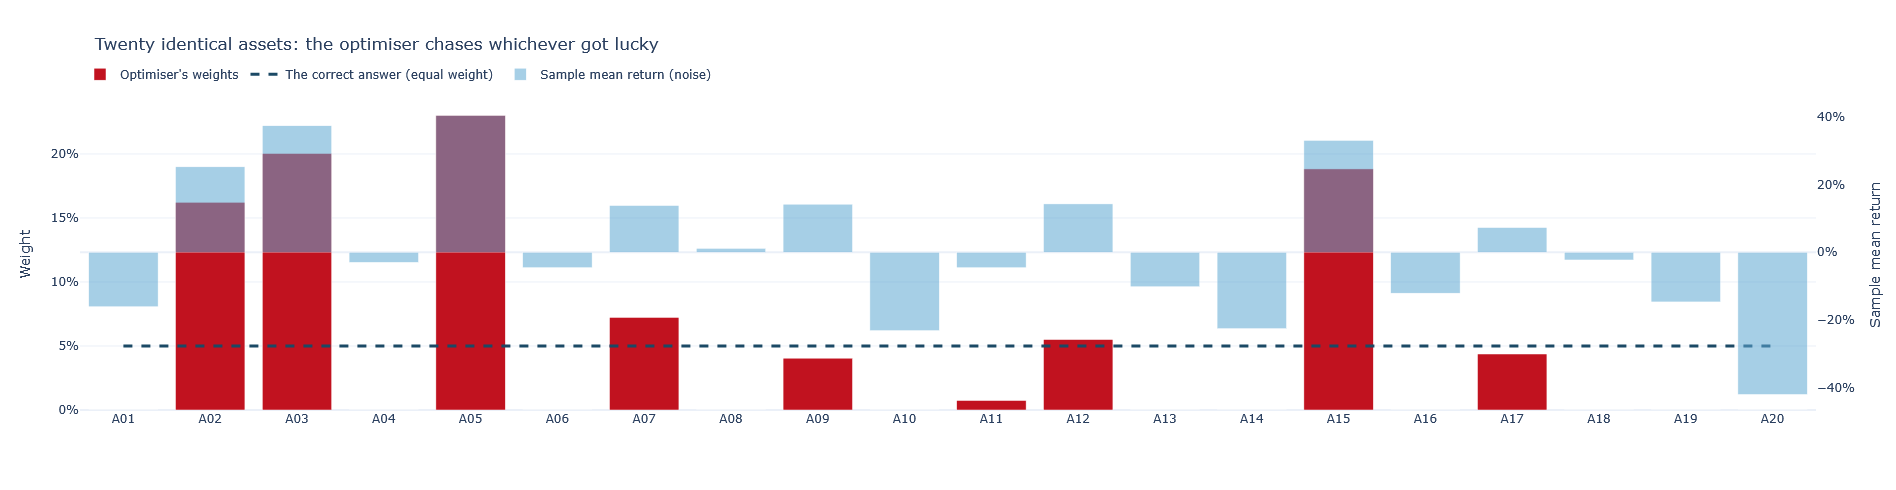

Compare the two bar series. The weights track the SAMPLE MEANS almost exactly --
and the sample means are 100% noise, because every true mean is identical.

That is what 'error maximiser' means: the optimiser cannot distinguish a genuinely
attractive asset from a lucky one, so it systematically overweights luck.


In [13]:
fig = go.Figure()
fig.add_trace(go.Bar(x=sim_df.columns, y=w_sim, name="Optimiser's weights",
                     marker_color=AIRM_COLOURS[1]))
fig.add_trace(go.Scatter(x=sim_df.columns, y=[1/n_assets]*n_assets, mode="lines",
                         name="The correct answer (equal weight)",
                         line=dict(color=AIRM_COLOURS[0], width=3, dash="dash")))
fig.add_trace(go.Bar(x=sim_df.columns, y=mu_s, name="Sample mean return (noise)",
                     marker_color=AIRM_COLOURS[2], opacity=0.55, yaxis="y2"))
fig.update_layout(
    title="Twenty identical assets: the optimiser chases whichever got lucky",
    template=AIRM_TEMPLATE, height=490, barmode="overlay",
    yaxis=dict(title="Weight", tickformat=".0%"),
    yaxis2=dict(title="Sample mean return", overlaying="y", side="right",
                tickformat=".0%", showgrid=False),
    legend=dict(orientation="h", y=1.13))
fig.show()

print("Compare the two bar series. The weights track the SAMPLE MEANS almost exactly --")
print("and the sample means are 100% noise, because every true mean is identical.")
print("\nThat is what 'error maximiser' means: the optimiser cannot distinguish a genuinely")
print("attractive asset from a lucky one, so it systematically overweights luck.")

### And the frontier itself is uncertain

If the inputs are noisy, the frontier drawn from them is noisy too. We can see this directly
by bootstrapping: resample the training period with replacement, re-estimate $\mu$ and
$\Sigma$, and re-draw the frontier. Do it thirty times.

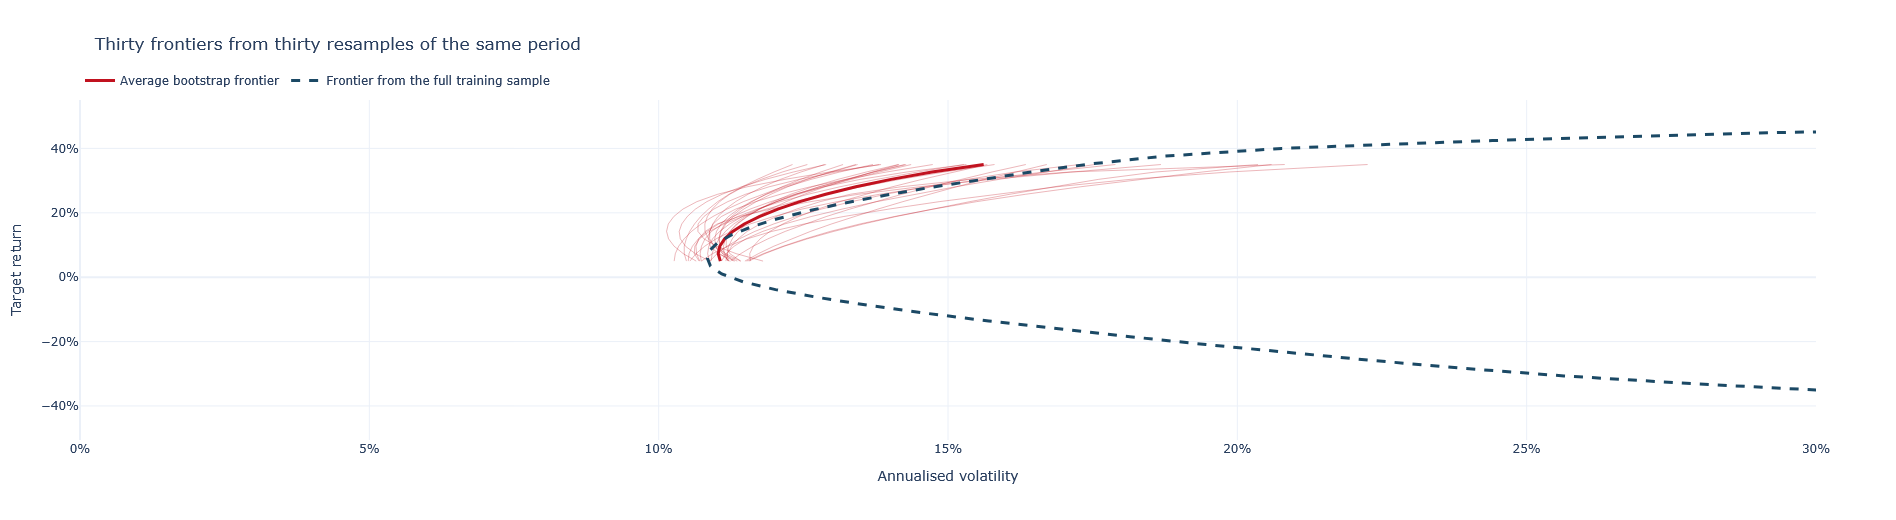

At a 5% target return : frontier volatility ranges 10.3% to 11.8%
At a 35% target return: frontier volatility ranges 12.3% to 22.3%

The uncertainty grows as you push for higher returns -- worst exactly where the
optimiser most wants to go. That single smooth curve was always a fiction.


In [14]:
rng_boot = np.random.default_rng(11)
targets = np.linspace(0.05, 0.35, 14)
n_boot = 30

boot_curves = []
for b in range(n_boot):
    idx = rng_boot.integers(0, len(train), len(train))
    rb = train.iloc[idx]
    mb, cb = ann_mu_cov(rb)
    vols = []
    for t in targets:
        w = min_vol_at_return(mb, cb, t)
        vols.append(np.sqrt(w @ cb @ w) if w is not None else np.nan)
    boot_curves.append(vols)
boot_curves = np.array(boot_curves)

fig = go.Figure()
for b in range(n_boot):
    fig.add_trace(go.Scatter(x=boot_curves[b], y=targets, mode="lines",
                             line=dict(color="rgba(193,18,31,0.30)", width=1),
                             showlegend=False, hoverinfo="skip"))
fig.add_trace(go.Scatter(x=np.nanmean(boot_curves, axis=0), y=targets, mode="lines",
                         name="Average bootstrap frontier",
                         line=dict(color=AIRM_COLOURS[1], width=3)))
fig.add_trace(go.Scatter(x=frontier["vol"], y=frontier["ret"], mode="lines",
                         name="Frontier from the full training sample",
                         line=dict(color=AIRM_COLOURS[0], width=3, dash="dash")))
fig.update_layout(title="Thirty frontiers from thirty resamples of the same period",
                  template=AIRM_TEMPLATE, height=520,
                  xaxis=dict(title="Annualised volatility", tickformat=".0%",range=[0, 0.30]),
                  yaxis=dict(title="Target return", tickformat=".0%"),
                  legend=dict(orientation="h", y=1.1))
fig.show()

lo, hi = np.nanmin(boot_curves[:, -1]), np.nanmax(boot_curves[:, -1])
lo0, hi0 = np.nanmin(boot_curves[:, 0]), np.nanmax(boot_curves[:, 0])
print(f"At a {targets[0]:.0%} target return : frontier volatility ranges {lo0:.1%} to {hi0:.1%}")
print(f"At a {targets[-1]:.0%} target return: frontier volatility ranges {lo:.1%} to {hi:.1%}")
print("\nThe uncertainty grows as you push for higher returns -- worst exactly where the")
print("optimiser most wants to go. That single smooth curve was always a fiction.")

### The pattern behind all of it

Look back at the results table and sort the four methods by how much **estimated input** each
one needs:

| Method | Inputs required | Sharpe IN | Sharpe OUT |
|---|---|---|---|
| Max Sharpe | $\mu$ **and** $\Sigma^{-1}$ | 2.02 | 0.76 |
| Min variance | $\Sigma^{-1}$ | 0.55 | 0.44 |
| Inverse volatility | individual $\sigma_i$ only | 0.43 | 1.49 |
| Equal weight | nothing at all | 0.32 | 1.82 |

The dividing line is sharp, and it is not about expected returns — it is about **matrix
inversion**. The two methods that invert a $44 \times 44$ covariance matrix estimated from
754 observations both land *below* 0.8 out of sample. The two that never invert anything both
land *above* 1.4.

Inverting an estimated covariance matrix is the single most dangerous operation in
quantitative finance, because inversion puts the *largest* weight on the directions estimated
*least* reliably. Lecture 3c is entirely about defusing it.

<details>
<summary><b>Why inversion amplifies noise</b></summary>

Write the eigendecomposition $\Sigma = \sum_i \lambda_i v_i v_i^\top$. Then

$$\Sigma^{-1} = \sum_i \frac{1}{\lambda_i} v_i v_i^\top$$

The *smallest* eigenvalues become the *largest* terms. And small eigenvalues correspond to
near-redundant combinations of assets — directions along which the data barely varies, so
they are precisely the worst-estimated. Inversion therefore takes your least reliable
information and gives it the most influence.

With $N$ assets and $T$ observations, the estimation quality depends on the ratio $T/N$.
We have $T/N = 754/44 \approx 17$, which sounds comfortable but is not: we are estimating
$N(N+1)/2 = 990$ distinct covariance parameters from 754 daily observations. There are more
unknowns than data points.

This is the object Lecture 3c repairs — by shrinking the eigenvalues (Ledoit–Wolf), by
deleting the ones indistinguishable from noise (Marchenko–Pastur denoising), or by avoiding
inversion altogether (hierarchical risk parity).

</details>

---

## 6. The cheapest fix in finance

Before any machine learning, try the crudest possible intervention: **forbid large
positions.** Cap every weight at some maximum and re-optimise. Nothing clever, one line of
code.

Move the slider.

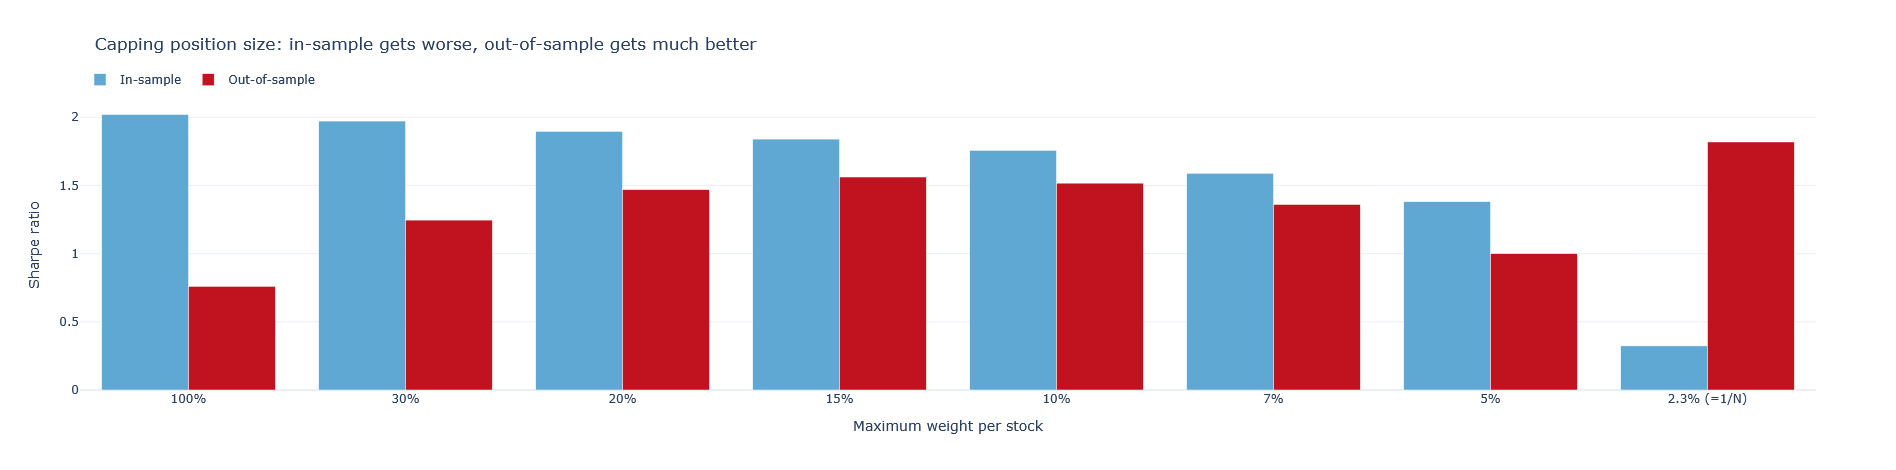

   cap Sharpe IN Sharpe OUT  holdings max_w
100.0%      2.02       0.76         6 48.6%
 30.0%      1.97       1.25         7 30.0%
 20.0%      1.90       1.47         9 20.0%
 15.0%      1.84       1.56         9 15.0%
 10.0%      1.76       1.52        11 10.0%
  7.0%      1.59       1.36        17  7.0%
  5.0%      1.38       1.00        21  5.0%
  2.3%      0.32       1.82        44  2.3%

Uncapped        : IN 2.02  OUT 0.76
Best cap (15%)  : IN 1.84  OUT 1.56

Capping anywhere between 10% and 20% roughly doubles out-of-sample Sharpe,
and the improvement is not sensitive to the exact value -- which is what you
want from a fix. Giving up ~0.2 of in-sample Sharpe bought ~0.8 of real Sharpe.


In [15]:
caps = [1.0, 0.30, 0.20, 0.15, 0.10, 0.07, 0.05, 1/N]
cap_rows = []
for cap in caps:
    w = max_sharpe(mu_tr, cov_tr, cap=cap)
    _, _, s_in = port_perf(w, train)
    _, _, s_out = port_perf(w, test)
    cap_rows.append({"cap": cap, "Sharpe IN": s_in, "Sharpe OUT": s_out,
                     "holdings": int((w > 0.01).sum()), "max_w": w.max()})
cap_df = pd.DataFrame(cap_rows)

fig = go.Figure()
labels = [f"{c:.0%}" if c > 1/N + 1e-9 else f"{c:.1%} (=1/N)" for c in cap_df["cap"]]
fig.add_trace(go.Bar(x=labels, y=cap_df["Sharpe IN"], name="In-sample",
                     marker_color=AIRM_COLOURS[2]))
fig.add_trace(go.Bar(x=labels, y=cap_df["Sharpe OUT"], name="Out-of-sample",
                     marker_color=AIRM_COLOURS[1]))
fig.update_layout(
    title="Capping position size: in-sample gets worse, out-of-sample gets much better",
    template=AIRM_TEMPLATE, height=470, barmode="group",
    xaxis_title="Maximum weight per stock", yaxis_title="Sharpe ratio",
    legend=dict(orientation="h", y=1.12))
fig.show()

# Exclude the degenerate cap of 1/N -- that leaves only ONE feasible portfolio
# (equal weight), so it is not really a constrained optimisation at all.
non_degenerate = cap_df[cap_df["cap"] > 1/N + 1e-9]
best = non_degenerate.loc[non_degenerate["Sharpe OUT"].idxmax()]
uncapped = cap_df.iloc[0]
print(cap_df.to_string(index=False, formatters={
    "cap": "{:.1%}".format, "Sharpe IN": "{:.2f}".format,
    "Sharpe OUT": "{:.2f}".format, "max_w": "{:.1%}".format}))
print(f"\nUncapped        : IN {uncapped['Sharpe IN']:.2f}  OUT {uncapped['Sharpe OUT']:.2f}")
print(f"Best cap ({best['cap']:.0%})  : IN {best['Sharpe IN']:.2f}  OUT {best['Sharpe OUT']:.2f}")
print(f"\nCapping anywhere between 10% and 20% roughly doubles out-of-sample Sharpe,")
print(f"and the improvement is not sensitive to the exact value -- which is what you")
print(f"want from a fix. Giving up ~0.2 of in-sample Sharpe bought ~0.8 of real Sharpe.")

Read that table carefully, because it contains the whole philosophy of robust portfolio
construction.

**Constraints make the in-sample result worse.** Of course they do — we removed options from
a maximisation problem. Every cap lowers the in-sample Sharpe.

**Constraints make the out-of-sample result better.** A 10% cap takes out-of-sample Sharpe
from 0.76 to 1.52 — exactly doubling it — and the best value on this grid, 15%, reaches 1.56.
Note how flat that improvement is across caps from 10% to 20%: a fix that does not depend on
tuning it precisely is a fix you can trust. The constraint is not "helping the optimiser find
a better answer"; it is *preventing the optimiser from acting on information it does not have.*

**And the tightest cap of all is equal weight.** Setting the cap to $1/N$ leaves only one
feasible portfolio, and it still wins. That is a humbling place to arrive at, and it is
exactly the gap Lecture 3c tries to close honestly.

This is regularisation, the same idea as ridge regression penalising large coefficients or
dropout in a neural network. Constraining a model to stop it fitting noise is one of the most
general ideas in machine learning, and here it is in its simplest form: *don't let it buy 49%
of one stock.*

---

## 7. The verdict

> **"The optimiser finds the best portfolio."**

**It finds the best portfolio *for the inputs you give it*** — and that is a much weaker
claim than it sounds, because our inputs were estimates dressed as facts.

Nothing here is a criticism of Markowitz. The mathematics is exactly right. The failure is
epistemological: mean-variance optimisation assumes $\mu$ and $\Sigma$ are known, and they
are not. Feed it noise and it will allocate confidently to noise, because it has no way to
express the sentence "I don't actually know."

Three things to carry into Lecture 3c:

1. **In-sample performance is not evidence.** It is a lower bound on how badly you can be
   fooled. Always split your sample.
2. **The enemy is $\Sigma^{-1}$.** Methods that avoid inverting an estimated covariance matrix
   were dramatically more robust here.
3. **Constraints work by removing freedom.** Any technique that stops the optimiser expressing
   confidence it has not earned will probably help.

Lecture 3c takes each of those seriously. Shrinkage pulls the covariance matrix towards
something better-conditioned. Denoising strips out the eigenvalues that are statistically
indistinguishable from random. Hierarchical risk parity replaces inversion with clustering
altogether. And we will judge all of them the only way that counts — out of sample, after
costs.

---

## 8. Exercises

### Core

**C1 — Move the split.** Change `SPLIT_FRAC` to 0.5 and then 0.75 and re-run. Does equal
weight always beat max Sharpe out of sample? What does the variability tell you about how
much confidence to place in any single backtest?

**C2 — Find the cap that works.** On our grid the 15% cap was best out of sample (1.56),
with 10% and 20% close behind. Search a finer grid and identify the best value. Now ask the awkward question: by choosing the cap using
out-of-sample results, what bias have you just introduced? (This is Lecture 5's subject.)

**C3 — Kill the expected returns.** Replace `mu_tr` with a vector where every asset has the
same expected return, then re-run `max_sharpe`. What portfolio do you get, and why? What does
this tell you about which input was driving the concentration?

**C4 — More assets, more trouble.** Rebuild with `PER_SECTOR = 8` (88 stocks) and re-run the
in/out-of-sample comparison. Does the optimiser's out-of-sample performance improve or
deteriorate as the universe grows? Relate your answer to the $T/N$ ratio.

### Stretch

**S1 — Which input hurts more?** In the known-truth simulation of Section 5, give the assets
genuinely *different* true expected returns and volatilities. Then perturb only $\mu$, and
separately only $\Sigma$, by comparable amounts, and measure the loss in true Sharpe versus the
true optimum. Chopra and Ziemba (1993) famously found errors in means to be roughly ten times
as costly as errors in variances — do you reproduce that? Be careful about how you scale the
two perturbations, because the answer depends on it.

**S2 — Shrink towards equal weight.** Implement $w_\lambda = \lambda w_{\text{MaxSharpe}} +
(1-\lambda) w_{\text{EqualWeight}}$ and plot out-of-sample Sharpe against $\lambda$ from 0 to
1. Where is the optimum, and what does that imply about how much of the optimiser's signal is
real?

**S3 — Rolling walk-forward.** Replace the single split with a rolling scheme: estimate on 24
months, hold for 1 month, roll forward. Compare max Sharpe and equal weight over all the
out-of-sample months, and include turnover. Does the optimiser's disadvantage grow once you
pay to rebalance it?

**S4 — Resampled efficiency.** Michaud's "resampled frontier" averages the *weights* across
bootstrap samples rather than reporting one optimisation. Implement it using the Section 5
bootstrap and test whether the averaged portfolio beats the single-sample optimum out of
sample.

---

## Summary

| | |
|---|---|
| **The claim** | "The optimiser finds the best portfolio" |
| **The verdict** | It optimises perfectly for inputs that are estimates, not facts |
| **The numbers** | Max Sharpe 2.02 in-sample → 0.76 out. Equal weight 0.32 → **1.82**. A 10% cap doubles the optimiser's out-of-sample Sharpe |

1. **The random-weight cloud is not the efficient frontier** — it reached 37% of the
   achievable Sharpe. Draw the frontier by solving the optimisation.
2. **The in-sample ranking inverted completely out of sample.** This is a documented,
   replicated result, not an accident of our data.
3. **Mean-variance optimisation is an error maximiser**: given twenty provably identical
   assets, it put 23% into whichever one got lucky.
4. **The frontier is a fiction of one sample** — bootstrapping it produces a wide band,
   widest at high target returns.
5. **Matrix inversion is the dividing line.** Methods needing $\Sigma^{-1}$ collapsed out of
   sample; methods needing no inversion thrived.
6. **Constraints help by removing freedom**, and the most constrained portfolio of all —
   equal weight — was hardest to beat.

**Next**, Lecture 3c brings in the machine learning: shrinkage, covariance denoising and
hierarchical clustering, all aimed squarely at the $\Sigma^{-1}$ problem we have just
diagnosed.